In [1]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame(usages)

<Axes: xlabel='prompt_tokens', ylabel='completion_tokens'>

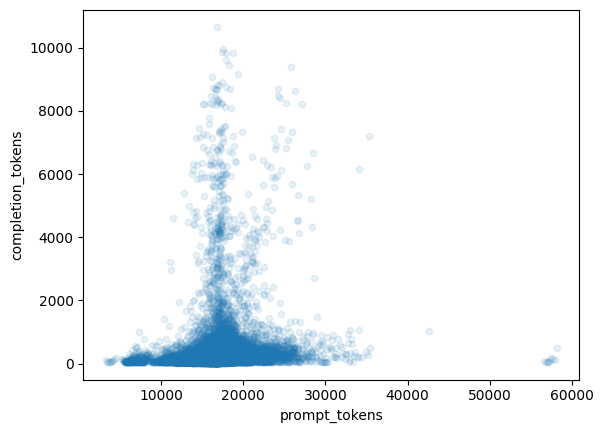

In [36]:
df.plot.scatter(x='prompt_tokens', y='completion_tokens', alpha=0.1)

<Axes: xlabel='prompt_tokens', ylabel='uncached_tokens'>

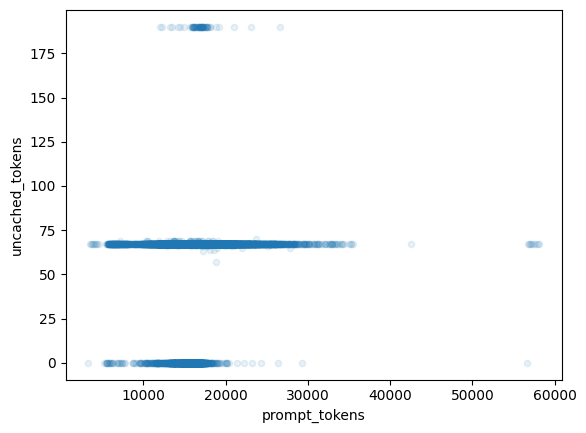

In [13]:
df.plot.scatter(x='prompt_tokens', y='uncached_tokens', alpha=0.1)

In [11]:
output_dir = Path('/data/projects/AgentScaling/adaptive_agentic_serving/output/SWE-bench_bm25_13K/')
usages = []
uncached_tokens = []
# Iterate all JSON files in output_dir using Path
for file_path in output_dir.glob("*.json"):
    with open(file_path, 'r') as f:
        data = json.load(f)
        assistent_msgs = [msg for msg in data['messages'] if msg['role'] == 'assistant']
        usage = [msg['extra']['response']['usage'] for msg in assistent_msgs]
        for i, u in enumerate(usage):
            usage[i]['conv_id'] = int(file_path.stem.split('.')[0].split('_')[-1])
            usage[i]['iter_id'] = i
        usages += usage
        uncached_tokens += [usage[0]['prompt_tokens']] + [usage[i+1]['prompt_tokens'] - usage[i]['total_tokens'] for i in range(len(usage)-1)]
df = pd.DataFrame(usages)
df['uncached_tokens'] = uncached_tokens

In [12]:
df[df['conv_id'] == 1839]

,completion_tokens,prompt_tokens,total_tokens,completion_tokens_details,prompt_tokens_details,conv_id,iter_id,uncached_tokens
7223,117,14864,14981,None,None,1839,0,14864
7224,45,15048,15093,None,None,1839,1,67
7225,51,15160,15211,None,None,1839,2,67
7226,55,15278,15333,None,None,1839,3,67
7227,63,15400,15463,None,None,1839,4,67
7228,100,15530,15630,None,None,1839,5,67
7229,556,15697,16253,None,None,1839,6,67
7230,56,16320,16376,None,None,1839,7,67
7231,315,16443,16758,None,None,1839,8,67
7232,394,16825,17219,None,None,1839,9,67


Text(0.5, 1.0, 'Uncached Tokens vs Prompt Tokens')

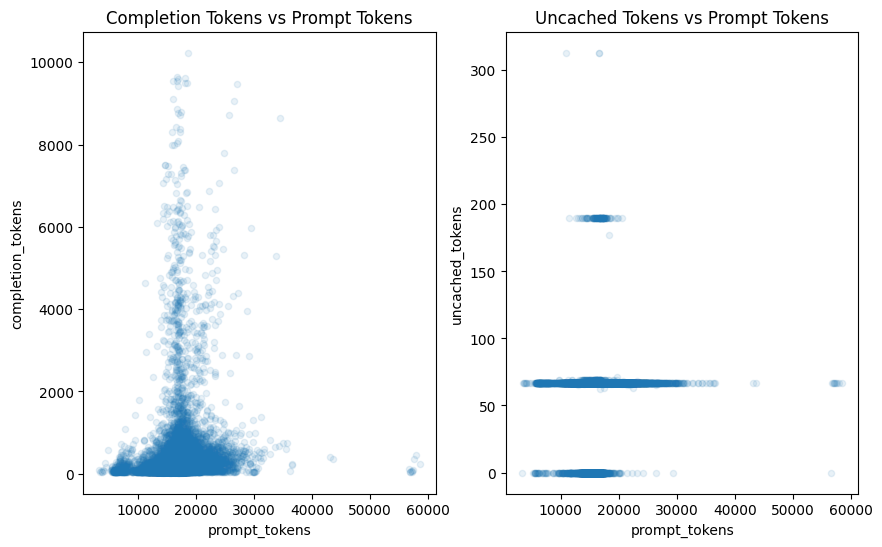

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
df.plot.scatter(x='prompt_tokens', y='completion_tokens', alpha=0.1, ax=ax[0])
df.plot.scatter(x='prompt_tokens', y='uncached_tokens', alpha=0.1, ax=ax[1])
ax[0].set_title('Completion Tokens vs Prompt Tokens')
ax[1].set_title('Uncached Tokens vs Prompt Tokens')


In [13]:
df

,completion_tokens,prompt_tokens,total_tokens,completion_tokens_details,prompt_tokens_details,conv_id,iter_id,uncached_tokens
0,147,16582,16729,None,None,1662,0,16582
1,40,16796,16836,None,None,1662,1,67
2,53,16903,16956,None,None,1662,2,67
3,46,17023,17069,None,None,1662,3,67
4,36,17136,17172,None,None,1662,4,67
...,...,...,...,...,...,...,...,...
22800,441,14625,15066,None,None,709,5,67
22801,749,15133,15882,None,None,709,6,67
22802,1243,15949,17192,None,None,709,7,67
22803,618,17259,17877,None,None,709,8,67


In [16]:
# Generate random prompts from Project Gutenberg books for non-prefix-caching inference
import requests
from transformers import AutoTokenizer
from tqdm import tqdm

URLS = [
    "https://www.gutenberg.org/files/1342/1342-0.txt",   # Pride and Prejudice
    "https://www.gutenberg.org/files/11/11-0.txt",       # Alice in Wonderland
    "https://www.gutenberg.org/files/84/84-0.txt",       # Frankenstein
    "https://www.gutenberg.org/files/1661/1661-0.txt",   # Sherlock Holmes
]

def strip_gutenberg(text: str) -> str:
    start = text.find("*** START")
    end = text.find("*** END")
    if start != -1 and end != -1 and start < end:
        return text[start:end]
    return text

# Fetch and build corpus from Gutenberg books
corpus = ""
for url in URLS:
    print(f"Fetching {url}")
    corpus += strip_gutenberg(requests.get(url, timeout=30).text) + "\n"

corpus = corpus.replace("\r", " ").replace("\n", " ")
sentences = [s.strip() for s in corpus.split(". ") if len(s.strip()) > 20]
assert len(sentences) > 1000, "Corpus unexpectedly small"

# Tokenizer for the model used during inference (adjust MODEL if needed)
MODEL = "meta-llama/Meta-Llama-3-8B"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def unique_anchor(conv_id: int, iter_id: int) -> str:
    """Guaranteed token-0 divergence to avoid prefix-caching."""
    codepoint = 0xE000 + (conv_id * 256 + iter_id) % 0x1900  # Stay in Unicode PUA
    return chr(codepoint) + " "

def generate_prompt_for_row(row, cursor) -> tuple[str, int]:
    """Generate a prompt with exactly row['uncached_tokens'] tokens. Returns (prompt, new_cursor)."""
    target_tokens = int(row['uncached_tokens'])
    text = unique_anchor(int(row['conv_id']), int(row['iter_id']))
    while True:
        sentence = sentences[cursor % len(sentences)]
        cursor += 1
        text += sentence + ". "
        tokens = tokenizer.encode(text, add_special_tokens=False)
        if len(tokens) >= target_tokens:
            tokens = tokens[:target_tokens]
            return tokenizer.decode(tokens), cursor

cursor = 0
prompt_records = []


for _, row in tqdm(df.iterrows(), total=len(df)):
    prompt, cursor = generate_prompt_for_row(row, cursor)
    prompt_records.append({
        'conv_id': int(row['conv_id']),
        'iter_id': int(row['iter_id']),
        'in_token_size': int(row['uncached_tokens']),
        'out_token_size': int(row['completion_tokens']),
        'prompt': prompt,
    })

print(f"Generated {len(prompt_records)} prompt records")
print("Sample record:", {k: v if k != 'prompt' else v[:80] + '...' for k, v in prompt_records[0].items()})

# Optional: save to JSON
# with open('generated_prompts.json', 'w') as f:
#     json.dump(prompt_records, f, indent=2)

Fetching https://www.gutenberg.org/files/1342/1342-0.txt
Fetching https://www.gutenberg.org/files/11/11-0.txt
Fetching https://www.gutenberg.org/files/84/84-0.txt
Fetching https://www.gutenberg.org/files/1661/1661-0.txt


100%|██████████| 22805/22805 [3:25:14<00:00,  1.85it/s]  

Generated 22805 prompt records
Sample record: {'conv_id': 1662, 'iter_id': 0, 'in_token_size': 16582, 'out_token_size': 147, 'prompt': '\uec00 *** START OF THE PROJECT GUTENBERG EBOOK 1342 ***                             ...'}


In [17]:
# Sort prompt_records by conv_id, then iter_id
sorted_prompt_records = sorted(prompt_records, key=lambda rec: (rec['conv_id'], rec['iter_id']))

import json
with open('prompt_records_sorted.json', 'w') as f:
    json.dump(sorted_prompt_records, f, indent=2)

print(f"Saved {len(sorted_prompt_records)} prompt records to 'prompt_records_sorted.json'")

Saved 22805 prompt records to 'prompt_records_sorted.json'


In [18]:
loaded_prompts = json.load(open('prompt_records_sorted.json', 'r'))